# Binary Classification Dataset Analysis

This notebook analyzes note onset distributions in the BCMI dataset for binary classification tasks.

**Goals:**
1. Load training+calibration data and convert to note onsets
2. Compare original vs stratified sampling datasets
3. Analyze correlation between note onset counts and music emotion
4. Split datasets by median onset count and analyze emotion distribution
5. Perform subject-specific analysis (subject='10', dataset='bcmi-training')

In [1]:
from pathlib import Path
import tempfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from fractions import Fraction
from typing import List

from eeg_music.bcmi import BCMICalibrationLoader, BCMITrainingLoader
from eeg_music.data import (
    EEGMusicDataset,
    MappedDataset,
    StratifiedSamplingDataset,
    copy_from_dataloader_into_dir,
    prepare_trial,
)
from eeg_music.onset_conversion import trial_wavraw_to_noteonsets
from eeg_music.emotion_utils import parse_music_emotion

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

/home/zmrocze/studia/uwr/magisterka/.devenv/state/venv/lib/python3.12/site-packages/speechbrain/utils/torch_audio_backend.py:57: UserWarning: torchaudio._backend.list_audio_backends has been deprecated. This deprecation is part of a large refactoring effort to transition TorchAudio into a maintenance phase. The decoding and encoding capabilities of PyTorch for both audio and video are being consolidated into TorchCodec. Please see https://github.com/pytorch/audio/issues/3902 for more information. It will be removed from the 2.9 release. 
  available_backends = torchaudio.list_audio_backends()
[   INFO   ] MusicExtractorSVM: no classifier models were configured by default


## 1. Load Training + Calibration Data

In [2]:
def create_combined_dataset(bcmi_root_path: str, save_dir: Path) -> EEGMusicDataset:
    """Load and combine BCMI training and calibration datasets."""
    training_loader = BCMITrainingLoader(
        f"{bcmi_root_path}/bcmi-training", dataset_name="bcmi-training"
    )
    training_loader.load_all_subjects()
    copy_from_dataloader_into_dir(training_loader, save_dir)
    del training_loader
    
    calibration_loader = BCMICalibrationLoader(
        f"{bcmi_root_path}/bcmi-calibration", dataset_name="bcmi-calibration"
    )
    calibration_loader.load_all_subjects()
    copy_from_dataloader_into_dir(calibration_loader, save_dir)
    del calibration_loader
    
    return EEGMusicDataset.load_ondisk(save_dir)

temp_save_dir = Path(tempfile.mkdtemp(prefix="bcmi_combined_"))
print(f"Temporary directory: {temp_save_dir}")
combined_dataset = create_combined_dataset("./datasets/bcmi", temp_save_dir)

Temporary directory: /tmp/bcmi_combined_174x0nio
Loading subject 08 (bcmi-training):


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the h

  ✓ Run 1 ses-3: 1008.0s, 36 events, 36 trials
  ✓ Run 2 ses-3: 1005.0s, 36 events, 36 trials
  ✓ Run 3 ses-3: 1010.0s, 36 events, 36 trials
  ✓ Run 4 ses-3: 1011.0s, 36 events, 36 trials
Loading subject 09 (bcmi-training):
  ✓ Run 1 ses-3: 1038.0s, 36 events, 36 trials
  ✓ Run 2 ses-3: 1052.0s, 36 events, 36 trials
  ✓ Run 3 ses-3: 1034.0s, 36 events, 36 trials
  ✓ Run 4 ses-3: 1036.0s, 36 events, 36 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the h

  ✓ Run 1 ses-1: 1045.0s, 36 events, 36 trials
  ✓ Run 2 ses-1: 1033.0s, 36 events, 36 trials
  ✓ Run 3 ses-1: 1034.0s, 36 events, 36 trials
  ✓ Run 4 ses-1: 1031.0s, 36 events, 36 trials
  ✓ Run 1 ses-2: 1036.0s, 36 events, 36 trials
  ✓ Run 2 ses-2: 1032.0s, 36 events, 36 trials
  ✓ Run 3 ses-2: 1016.0s, 36 events, 36 trials


...

  ✓ Run 1: 927.0s, 36 events, 18 trials
  ✓ Run 2: 868.0s, 36 events, 18 trials
  ✓ Run 3: 852.0s, 36 events, 18 trials
  ✓ Run 4: 823.0s, 36 events, 18 trials
  ✓ Run 5: 836.0s, 36 events, 18 trials
Loading subject 17 (bcmi-calibration):
  ✓ Run 1: 954.0s, 36 events, 18 trials
  ✓ Run 2: 829.0s, 36 events, 18 trials
  ✓ Run 3: 861.0s, 36 events, 18 trials
  ✓ Run 4: 840.0s, 36 events, 18 trials
  ✓ Run 5: 830.0s, 36 events, 18 trials
Loading subject 18 (bcmi-calibration):
  ✓ Run 1: 961.0s, 36 events, 18 trials
  ✓ Run 2: 895.0s, 36 events, 18 trials
  ✓ Run 3: 847.0s, 36 events, 18 trials
  ✓ Run 4: 847.0s, 36 events, 18 trials
  ✓ Run 5: 830.0s, 36 events, 18 trials
Loading subject 19 (bcmi-calibration):
  ✓ Run 1: 960.0s, 36 events, 18 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the h

  ✓ Run 2: 964.0s, 36 events, 18 trials
  ✓ Run 3: 869.0s, 36 events, 18 trials
  ✓ Run 4: 856.0s, 36 events, 18 trials
  ✓ Run 5: 853.0s, 36 events, 18 trials


/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: Invalid measurement date encountered in the header.
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA1" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "UserReport". Type of channel "VA2" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)
/home/zmrocze/studia/uwr/magisterka/src/eeg_music/bcmi.py:371: RuntimeWarning: No BIDS -> MNE mapping found for channel type "MetaData". Type of channel "VAtarg" will be set to "misc".
  raw = read_raw_bids(bids_path, verbose=False)


Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 secs...
Reading 0 ... 20999  =      0.000 ...    20.999 

In [3]:
print(f"Total trials in combined dataset: {len(combined_dataset)}")
print(f"\nDataset composition:")
print(combined_dataset.df['dataset'].value_counts())

Total trials in combined dataset: 5130

Dataset composition:
dataset
bcmi-training       3456
bcmi-calibration    1674
Name: count, dtype: int64


## 2. Convert to Note Onsets

We'll use 1-second chunks with 512 Hz sampling rate.

In [4]:
noteonset_ds = MappedDataset(
    combined_dataset,
    lambda t: trial_wavraw_to_noteonsets(
        prepare_trial(t, eeg_resample=512)
    )
)

print(f"Note onset dataset size: {len(noteonset_ds)}")

Note onset dataset size: 5130


In [5]:
# Inspect a sample trial
sample_trial = noteonset_ds[0]
print(sample_trial)
print(f"\nNote onsets: {sample_trial.music_data.get_music()}")

TrialData(
  dataset=bcmi-training, subject=08, session=3, run=1, trial_id=trial_1,
  music_filename=1-6_3_first.wav,
  eeg=RawEeg(sfreq=512, chans=37, secs=19.998, samples=10239),
  music=NoteOnsets
)

Note onsets: NoteOnsets(onset_times=array([1.1609977e-02, 9.2879817e-02, 9.2879820e-01, 1.8111565e+00,
       2.5890250e+00, 3.4713833e+00, 4.4582314e+00, 5.4450793e+00,
       6.4435372e+00, 7.1633558e+00, 8.2198639e+00, 8.9977322e+00,
       9.9729710e+00, 1.0843719e+01, 1.1726077e+01, 1.2492335e+01,
       1.3363084e+01, 1.4361542e+01, 1.5348390e+01, 1.6335238e+01,
       1.7066668e+01, 1.8111565e+01, 1.8912653e+01, 1.9876282e+01,
       2.0003990e+01], dtype=float32), sample_rate=44100, duration_seconds=20.0)


## 3. Create Stratified Sampling Dataset

We'll create a stratified version with 5 strata for comparison.

In [6]:
stratified_ds = StratifiedSamplingDataset(
    base_dataset=noteonset_ds,
    n_strata=5,
    trial_length_secs=Fraction(4, 1)
)

print(f"Stratified dataset size: {len(stratified_ds)} (= {len(noteonset_ds)} × 5)")

Stratified dataset size: 25650 (= 5130 × 5)


## 4. Count Note Onsets Per Trial

For both datasets, we'll count how many note onsets are in each trial.

In [8]:
def count_onsets_in_dataset(dataset, name: str) -> pd.DataFrame:
    """Count note onsets for each trial in the dataset."""
    onset_counts = []
    emotions = []
    datasets = []
    subjects = []
    
    for i in range(len(dataset)):
        trial = dataset[i]
        music = trial.music_data.get_music()
        n_onsets = len(music.onset_times)
        emotion = parse_music_emotion(trial.music_filename.filename, trial.dataset)
        
        onset_counts.append(n_onsets)
        emotions.append(emotion)
        datasets.append(trial.dataset)
        subjects.append(trial.subject)
    
    return pd.DataFrame({
        'onset_count': onset_counts,
        'emotion': emotions,
        'dataset': datasets,
        'subject': subjects,
        'dataset_type': name
    })

print("Counting onsets in original dataset...")
original_counts = count_onsets_in_dataset(noteonset_ds, "original")

print("Counting onsets in stratified dataset...")
stratified_counts = count_onsets_in_dataset(stratified_ds, "stratified")

print("Done!")

Counting onsets in original dataset...
Counting onsets in stratified dataset...
Done!


In [9]:
# Display summary statistics
print("Original Dataset - Onset Count Statistics:")
print(original_counts['onset_count'].describe())
print(f"\nStratified Dataset - Onset Count Statistics (sampled):")
print(stratified_counts['onset_count'].describe())

Original Dataset - Onset Count Statistics:
count    5130.000000
mean       35.981092
std        13.568692
min         2.000000
25%        23.000000
50%        35.000000
75%        49.000000
max        65.000000
Name: onset_count, dtype: float64

Stratified Dataset - Onset Count Statistics (sampled):
count    25650.000000
mean         7.114581
std          3.524267
min          0.000000
25%          4.000000
50%          6.000000
75%         10.000000
max         19.000000
Name: onset_count, dtype: float64


## 5. Histogram of Note Onset Counts

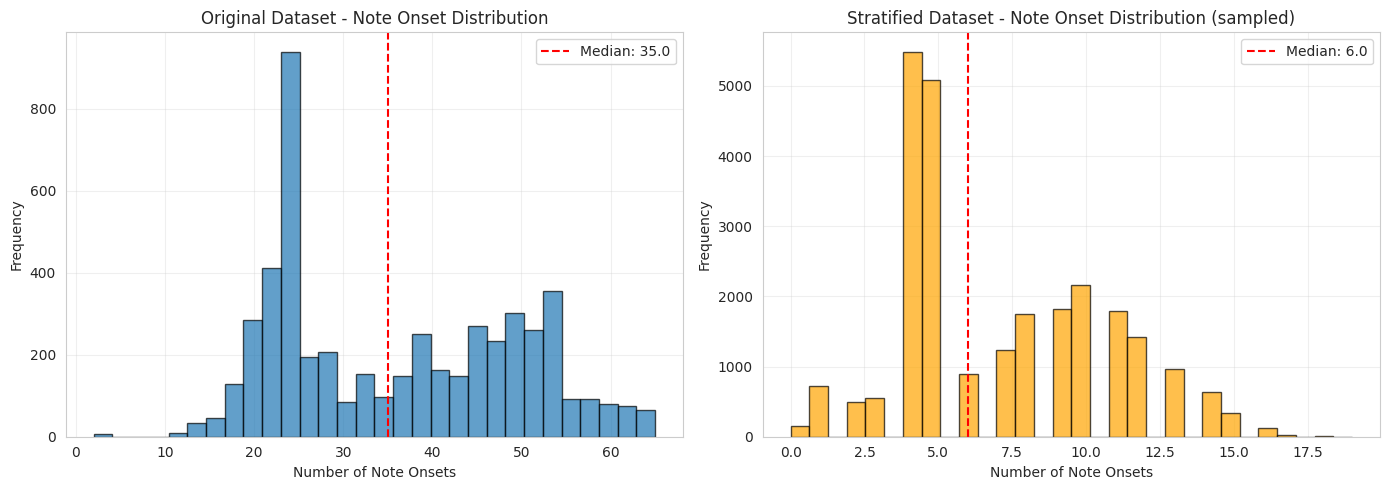

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original dataset
axes[0].hist(original_counts['onset_count'], bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(original_counts['onset_count'].median(), color='red', linestyle='--', 
                label=f"Median: {original_counts['onset_count'].median():.1f}")
axes[0].set_xlabel('Number of Note Onsets')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Original Dataset - Note Onset Distribution')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Stratified dataset
axes[1].hist(stratified_counts['onset_count'], bins=30, edgecolor='black', alpha=0.7, color='orange')
axes[1].axvline(stratified_counts['onset_count'].median(), color='red', linestyle='--',
                label=f"Median: {stratified_counts['onset_count'].median():.1f}")
axes[1].set_xlabel('Number of Note Onsets')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Stratified Dataset - Note Onset Distribution (sampled)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Correlation: Note Onsets vs Music Emotion

Analyze how note onset counts correlate with music emotion (1-9).

In [11]:
# Filter out None emotions
original_with_emotion = original_counts[original_counts['emotion'].notna()].copy()
stratified_with_emotion = stratified_counts[stratified_counts['emotion'].notna()].copy()

print(f"Original dataset: {len(original_with_emotion)} trials with emotion labels")
print(f"Stratified dataset: {len(stratified_with_emotion)} trials with emotion labels")

Original dataset: 5130 trials with emotion labels
Stratified dataset: 25650 trials with emotion labels


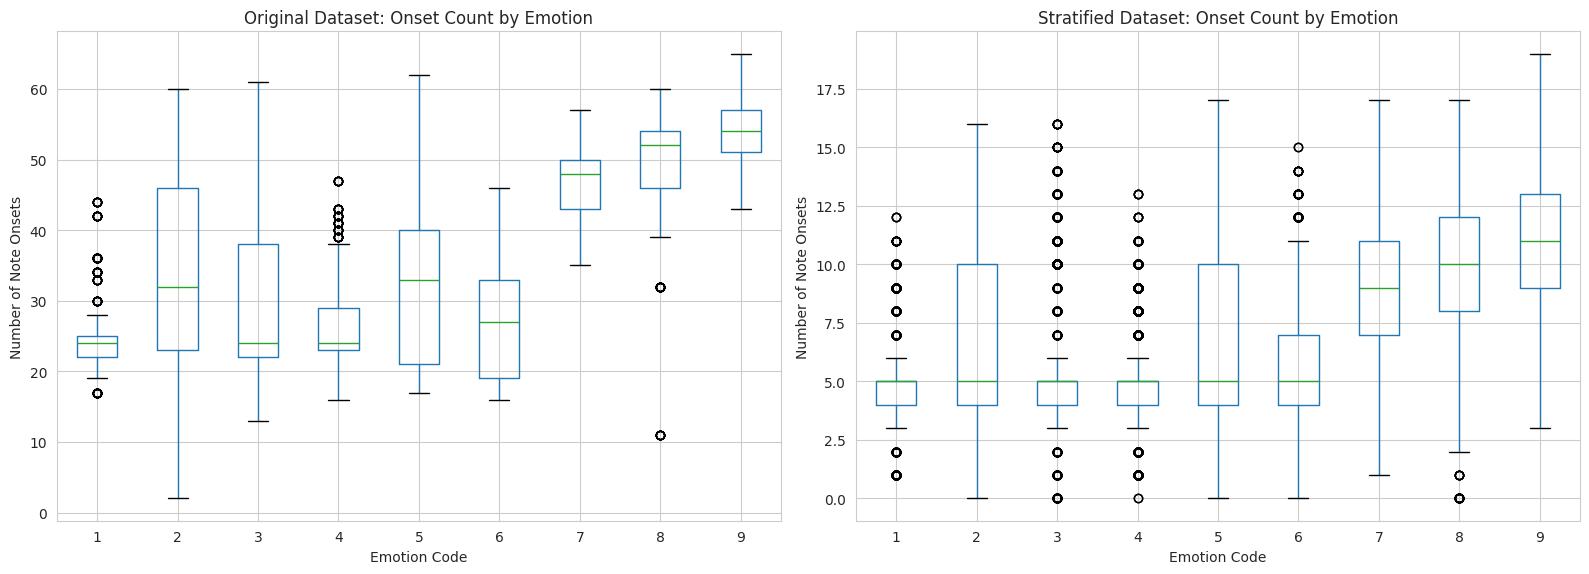

In [12]:
# Box plot: Onset counts by emotion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Original dataset
original_with_emotion.boxplot(column='onset_count', by='emotion', ax=axes[0])
axes[0].set_xlabel('Emotion Code')
axes[0].set_ylabel('Number of Note Onsets')
axes[0].set_title('Original Dataset: Onset Count by Emotion')
axes[0].get_figure().suptitle('')  # Remove default title

# Stratified dataset
stratified_with_emotion.boxplot(column='onset_count', by='emotion', ax=axes[1])
axes[1].set_xlabel('Emotion Code')
axes[1].set_ylabel('Number of Note Onsets')
axes[1].set_title('Stratified Dataset: Onset Count by Emotion')
axes[1].get_figure().suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

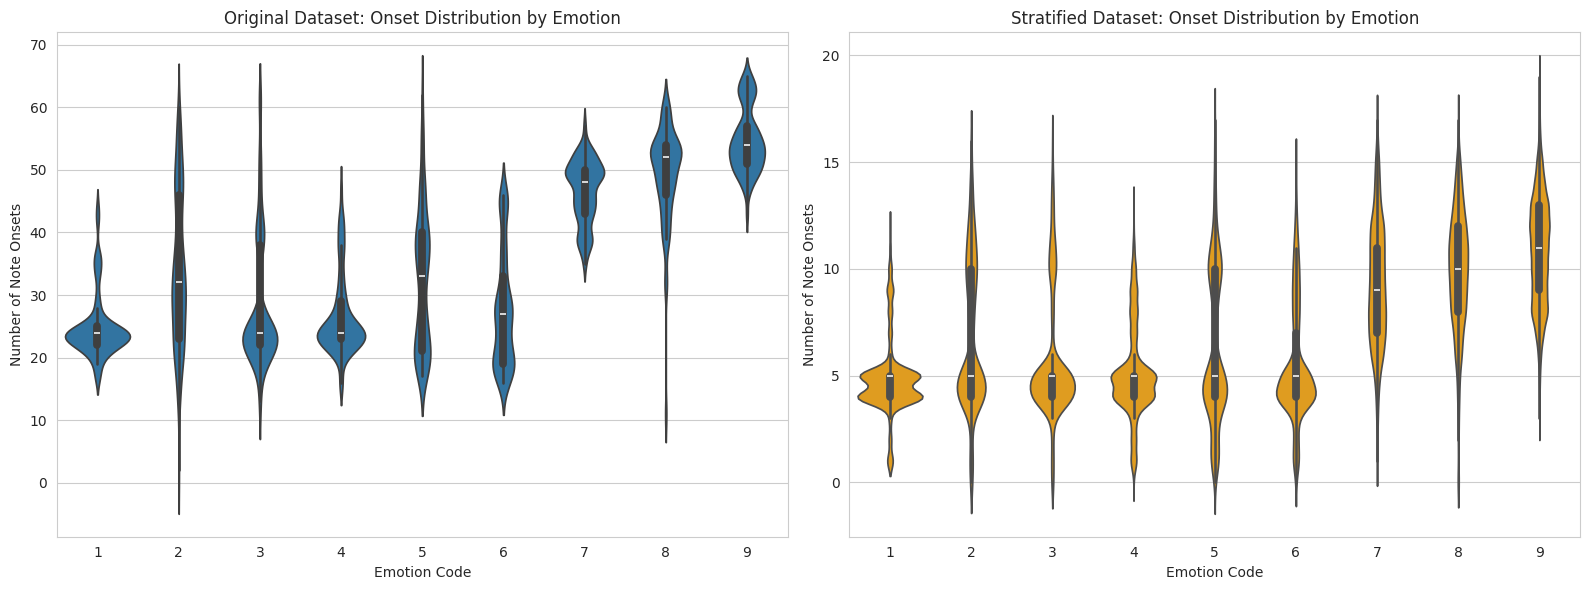

In [13]:
# Violin plot for better distribution visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.violinplot(data=original_with_emotion, x='emotion', y='onset_count', ax=axes[0])
axes[0].set_xlabel('Emotion Code')
axes[0].set_ylabel('Number of Note Onsets')
axes[0].set_title('Original Dataset: Onset Distribution by Emotion')

sns.violinplot(data=stratified_with_emotion, x='emotion', y='onset_count', ax=axes[1], color='orange')
axes[1].set_xlabel('Emotion Code')
axes[1].set_ylabel('Number of Note Onsets')
axes[1].set_title('Stratified Dataset: Onset Distribution by Emotion')

plt.tight_layout()
plt.show()

In [14]:
# Compute correlation statistics
from scipy.stats import pearsonr, spearmanr

print("Original Dataset - Correlation Analysis:")
pearson_r, pearson_p = pearsonr(original_with_emotion['emotion'], original_with_emotion['onset_count'])
spearman_r, spearman_p = spearmanr(original_with_emotion['emotion'], original_with_emotion['onset_count'])
print(f"  Pearson correlation: r={pearson_r:.3f}, p={pearson_p:.4f}")
print(f"  Spearman correlation: ρ={spearman_r:.3f}, p={spearman_p:.4f}")

print("\nStratified Dataset - Correlation Analysis:")
pearson_r_s, pearson_p_s = pearsonr(stratified_with_emotion['emotion'], stratified_with_emotion['onset_count'])
spearman_r_s, spearman_p_s = spearmanr(stratified_with_emotion['emotion'], stratified_with_emotion['onset_count'])
print(f"  Pearson correlation: r={pearson_r_s:.3f}, p={pearson_p_s:.4f}")
print(f"  Spearman correlation: ρ={spearman_r_s:.3f}, p={spearman_p_s:.4f}")

Original Dataset - Correlation Analysis:
  Pearson correlation: r=0.642, p=0.0000
  Spearman correlation: ρ=0.613, p=0.0000

Stratified Dataset - Correlation Analysis:
  Pearson correlation: r=0.495, p=0.0000
  Spearman correlation: ρ=0.495, p=0.0000


In [15]:
# Mean onset count by emotion
print("\nOriginal Dataset - Mean Onset Count by Emotion:")
emotion_means_orig = original_with_emotion.groupby('emotion')['onset_count'].agg(['mean', 'std', 'count'])
print(emotion_means_orig)

print("\nStratified Dataset - Mean Onset Count by Emotion:")
emotion_means_strat = stratified_with_emotion.groupby('emotion')['onset_count'].agg(['mean', 'std', 'count'])
print(emotion_means_strat)


Original Dataset - Mean Onset Count by Emotion:
              mean        std  count
emotion                             
1        24.811189   5.148514    572
2        34.067826  12.375537    575
3        28.276896  10.659650    567
4        26.457539   6.387543    577
5        32.365897  11.173703    563
6        27.599650   9.150935    572
7        46.643357   5.037381    572
8        49.136525   7.986054    564
9        54.755282   5.181194    568

Stratified Dataset - Mean Onset Count by Emotion:
              mean       std  count
emotion                            
1         4.823776  1.711552   2860
2         6.804522  3.518029   2875
3         5.688183  2.965358   2835
4         5.097747  2.108733   2885
5         6.293073  3.594951   2815
6         5.447203  2.721221   2860
7         9.270979  2.838980   2860
8         9.845745  2.853021   2820
9        10.817958  2.477861   2840


## 7. Split by Median Onset Count

Split datasets into two halves based on median onset count and analyze emotion distribution.


Original Dataset - Median onset count: 35.0

Low onset group (≤ 35.0): 2597 trials
High onset group (> 35.0): 2533 trials

Low onset group - Emotion counts:
emotion
1    528
2    345
3    421
4    500
5    320
6    445
7     10
8     28
Name: count, dtype: int64

High onset group - Emotion counts:
emotion
1     44
2    230
3    146
4     77
5    243
6    127
7    562
8    536
9    568
Name: count, dtype: int64


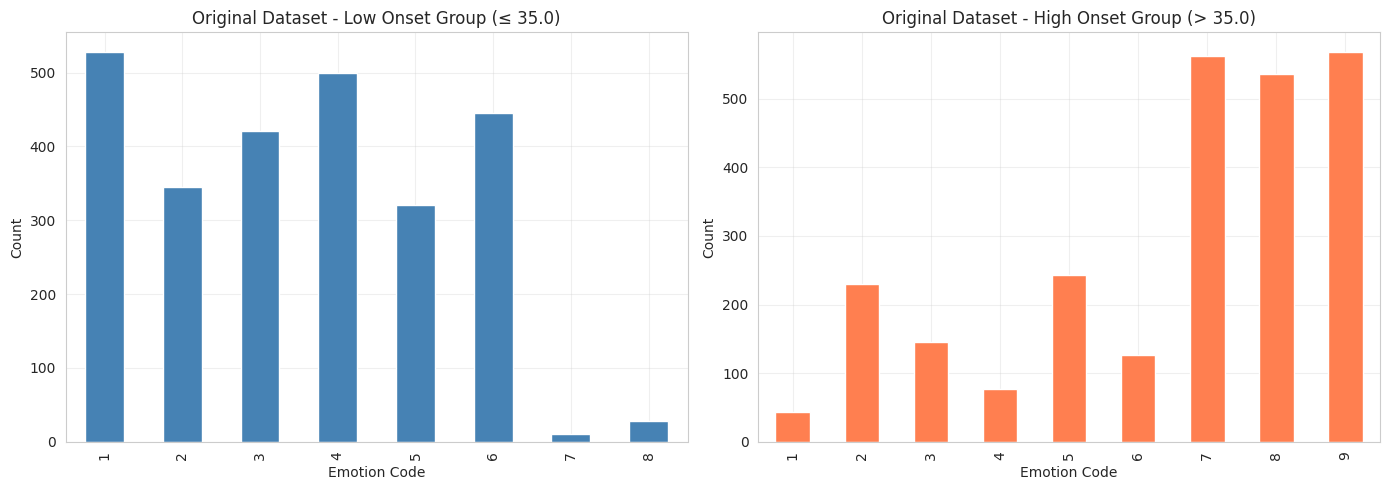

In [16]:
def split_by_median_and_analyze(df: pd.DataFrame, name: str):
    """Split by median onset count and show emotion distribution."""
    median_onset = df['onset_count'].median()
    print(f"\n{'='*60}")
    print(f"{name} - Median onset count: {median_onset:.1f}")
    print(f"{'='*60}")
    
    low_onsets = df[df['onset_count'] <= median_onset]
    high_onsets = df[df['onset_count'] > median_onset]
    
    print(f"\nLow onset group (≤ {median_onset:.1f}): {len(low_onsets)} trials")
    print(f"High onset group (> {median_onset:.1f}): {len(high_onsets)} trials")
    
    # Emotion distribution in each half
    low_emotions = low_onsets[low_onsets['emotion'].notna()]['emotion'].value_counts().sort_index()
    high_emotions = high_onsets[high_onsets['emotion'].notna()]['emotion'].value_counts().sort_index()
    
    print(f"\nLow onset group - Emotion counts:")
    print(low_emotions)
    
    print(f"\nHigh onset group - Emotion counts:")
    print(high_emotions)
    
    # Visualization
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    low_emotions.plot(kind='bar', ax=axes[0], color='steelblue')
    axes[0].set_xlabel('Emotion Code')
    axes[0].set_ylabel('Count')
    axes[0].set_title(f'{name} - Low Onset Group (≤ {median_onset:.1f})')
    axes[0].grid(alpha=0.3)
    
    high_emotions.plot(kind='bar', ax=axes[1], color='coral')
    axes[1].set_xlabel('Emotion Code')
    axes[1].set_ylabel('Count')
    axes[1].set_title(f'{name} - High Onset Group (> {median_onset:.1f})')
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return low_onsets, high_onsets

# Analyze original dataset
low_orig, high_orig = split_by_median_and_analyze(original_counts, "Original Dataset")


Stratified Dataset - Median onset count: 6.0

Low onset group (≤ 6.0): 13388 trials
High onset group (> 6.0): 12262 trials

Low onset group - Emotion counts:
emotion
1    2525
2    1644
3    2210
4    2300
5    1713
6    2099
7     489
8     323
9      85
Name: count, dtype: int64

High onset group - Emotion counts:
emotion
1     335
2    1231
3     625
4     585
5    1102
6     761
7    2371
8    2497
9    2755
Name: count, dtype: int64


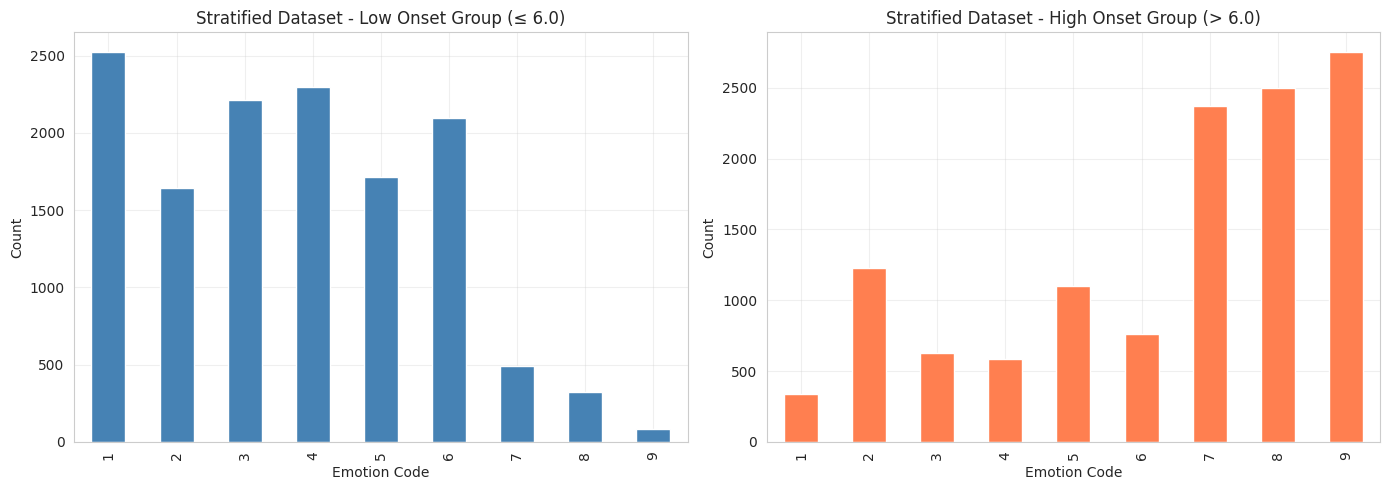

In [17]:
# Analyze stratified dataset
low_strat, high_strat = split_by_median_and_analyze(stratified_counts, "Stratified Dataset")

## 8. Subject-Specific Analysis

Filter to subject='10', dataset='bcmi-training' and perform the same median split analysis.

In [18]:
# Filter original dataset for subject 10, bcmi-training
subject_filter = (original_counts['subject'] == '10') & (original_counts['dataset'] == 'bcmi-training')
subject_10_data = original_counts[subject_filter].copy()

print(f"Subject 10 (bcmi-training) - Total trials: {len(subject_10_data)}")
print(f"\nOnset count statistics:")
print(subject_10_data['onset_count'].describe())

Subject 10 (bcmi-training) - Total trials: 432

Onset count statistics:
count    432.000000
mean      36.747685
std       13.269428
min        2.000000
25%       24.000000
50%       36.000000
75%       49.000000
max       64.000000
Name: onset_count, dtype: float64


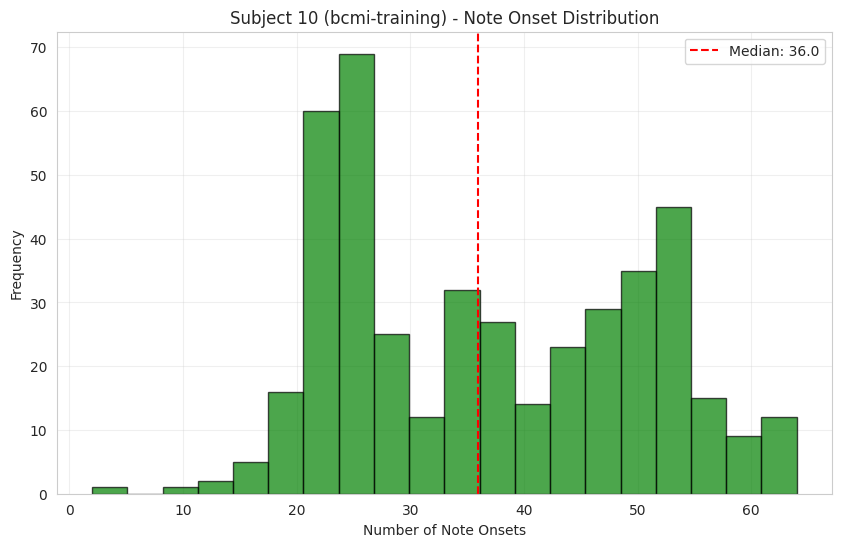

In [19]:
# Histogram for subject 10
plt.figure(figsize=(10, 6))
plt.hist(subject_10_data['onset_count'], bins=20, edgecolor='black', alpha=0.7, color='green')
plt.axvline(subject_10_data['onset_count'].median(), color='red', linestyle='--',
            label=f"Median: {subject_10_data['onset_count'].median():.1f}")
plt.xlabel('Number of Note Onsets')
plt.ylabel('Frequency')
plt.title('Subject 10 (bcmi-training) - Note Onset Distribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Subject 10 (bcmi-training) - Median onset count: 36.0

Low onset group (≤ 36.0): 223 trials
High onset group (> 36.0): 209 trials

Low onset group - Emotion counts:
emotion
1    46
2    28
3    42
4    39
5    29
6    37
7     1
8     1
Name: count, dtype: int64

High onset group - Emotion counts:
emotion
1     2
2    20
3     6
4     9
5    19
6    11
7    47
8    47
9    48
Name: count, dtype: int64


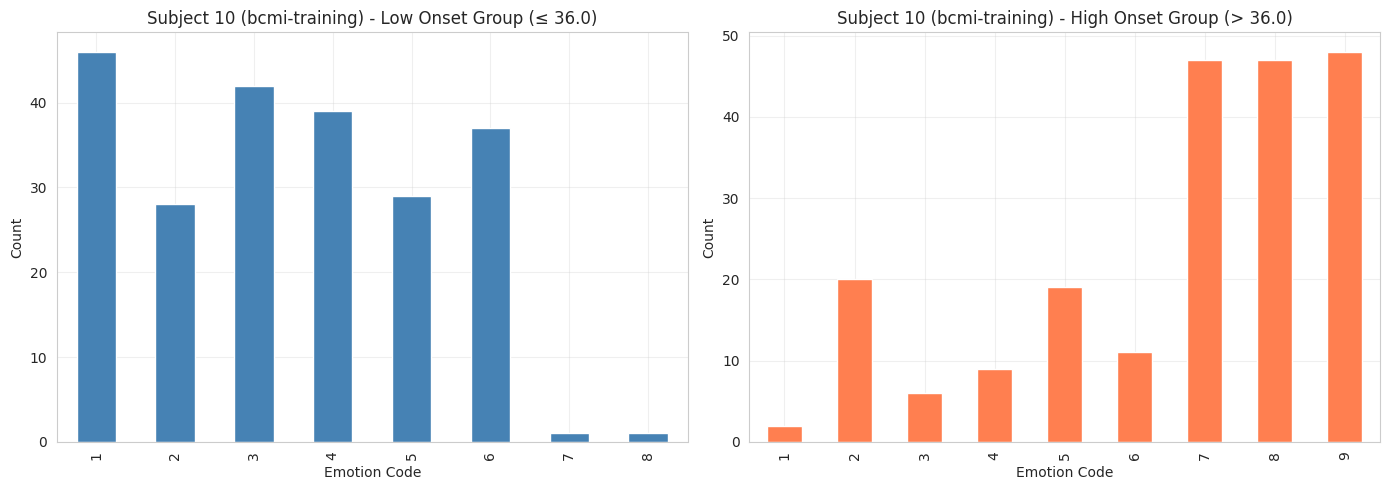

In [20]:
# Split by median for subject 10
low_subj10, high_subj10 = split_by_median_and_analyze(
    subject_10_data, 
    "Subject 10 (bcmi-training)"
)

## 9. Summary Statistics Table

In [21]:
# Create summary table
summary_data = {
    'Dataset': ['Original', 'Stratified (sampled)', 'Subject 10'],
    'Total Trials': [len(original_counts), len(stratified_counts), len(subject_10_data)],
    'Mean Onsets': [
        original_counts['onset_count'].mean(),
        stratified_counts['onset_count'].mean(),
        subject_10_data['onset_count'].mean()
    ],
    'Median Onsets': [
        original_counts['onset_count'].median(),
        stratified_counts['onset_count'].median(),
        subject_10_data['onset_count'].median()
    ],
    'Std Dev': [
        original_counts['onset_count'].std(),
        stratified_counts['onset_count'].std(),
        subject_10_data['onset_count'].std()
    ],
    'Min Onsets': [
        original_counts['onset_count'].min(),
        stratified_counts['onset_count'].min(),
        subject_10_data['onset_count'].min()
    ],
    'Max Onsets': [
        original_counts['onset_count'].max(),
        stratified_counts['onset_count'].max(),
        subject_10_data['onset_count'].max()
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)
print(summary_df.to_string(index=False))


SUMMARY STATISTICS
             Dataset  Total Trials  Mean Onsets  Median Onsets   Std Dev  Min Onsets  Max Onsets
            Original          5130    35.981092           35.0 13.568692           2          65
Stratified (sampled)         25650     7.114581            6.0  3.524267           0          19
          Subject 10           432    36.747685           36.0 13.269428           2          64


## 10. Key Findings

Run all cells above to generate the analysis. Key questions to answer:

1. **Distribution Shape**: Are note onsets uniformly distributed or skewed?
2. **Stratified vs Original**: Does stratified sampling change the onset distribution?
3. **Emotion Correlation**: Is there a significant correlation between emotion codes and onset counts?
4. **Median Split Balance**: When splitting by median, how are emotions distributed in each half?
5. **Subject Variability**: Does subject 10 show different patterns than the overall dataset?